In [1]:
import random
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from effcv.dataloaders import get_uc_cell_loaders


Centercrop of 250x250 removes the numbers on the side of the image.

How small can we make the images without losing any information? 
- Batchsize = Dataset size
- Sum over all dimensions and see how small we can make the center crop without losing any non-null values
- As this this is the cell, we can figure out where something can theoretically be

Until 206x206 no data loss. To account for other differently shaped cells, we pick centercrop 220

Our training data is quite sparse. Only 1.3% of the values are not zero, even with the centercrop. How can we leverage that?

# Naive approaches

## Scikit-image labeling

Following the approach in https://scikit-image.org/docs/0.25.x/auto_examples/segmentation/plot_label.html 

The following code pulls a random image and shows the bboxes that the approach identified and the number of FOCI

In [2]:
train_loader, _ = get_uc_cell_loaders(batch_size=1, data_dir=Path("../data/uc_cells"), get_bboxes=True)

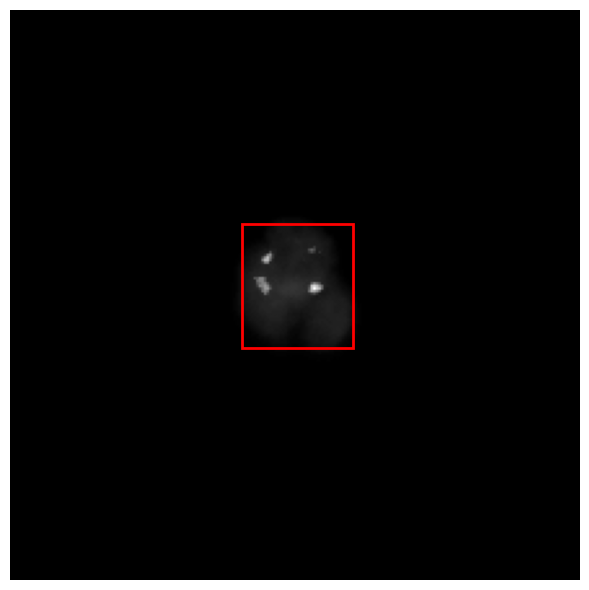

1


In [3]:
dataset = train_loader.dataset  # access the underlying dataset
random_idx = random.randint(0, len(dataset) - 1)

random_img, img_label = dataset[random_idx]
random_img = random_img.squeeze().numpy()

fig, ax = plt.subplots(figsize=(10, 6))

ax.imshow(random_img, cmap="grey")
if img_label["count"] > 0:
	for region in img_label["bboxes"]:
		minr, minc, maxr, maxc = region
		rect = mpatches.Rectangle(
			(minc, minr),
			maxc - minc,
			maxr - minr,
			fill=False,
			edgecolor="red",
			linewidth=2,
		)
		ax.add_patch(rect)

	ax.set_axis_off()
	plt.tight_layout()
	plt.show()

print(img_label["count"])

## 

## Zweite "naive" Idee

Immer noch kein machine learning, aber vielleicht mit etwas mehr nachdenken könnte man auf den folgenden Algorithmus kommen

1. Light Blurring e.g. 3x3 conv kernel
2. Otsu thresholding
3. Distance transform https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.distance_transform_edt.html#scipy.ndimage.distance_transform_edt
4. Lokale Maxima als Marker definieren (mit Mindestabstand + Mindestwert oder sowas)
5. Watershed segmentation


# Machine Learning approaches

## Simple CNN architecture

[TODO]

# Visualisierung

In [4]:
def plot_pixel_stats(imgs_tensor: torch.Tensor) -> None:
	"""
	Creates subplots of pixel distribution etc for cell images.
	"""
	# prepare data for plots
	_, C, H, W = imgs_tensor.shape
	total_pixels_per_img = C * H * W

	nonzero_counts_percentage = [torch.count_nonzero(img).item() / total_pixels_per_img * 100 for img in imgs_tensor]
	nonzero_counts = [torch.count_nonzero(img).item() for img in imgs_tensor]

	all_pixels = imgs_tensor.flatten().numpy()

	binary_imgs = imgs_tensor.squeeze(1).numpy() > 0
	heatmap = binary_imgs.sum(axis=0)

	# create subplots
	fig, axs = plt.subplots(2, 2, figsize=(14, 10))
	fig.suptitle("Analysis of Cell Image Dataset", fontsize=18, weight="bold")

	# Non-Zero Pixel Histogram (percentage)
	axs[0, 0].hist(nonzero_counts_percentage, bins=30, color="#4C72B0", edgecolor="white", alpha=0.9)
	axs[0, 0].set_title("Non-Zero Pixel % per Image")
	axs[0, 0].set_xlabel("% Non-Zero Pixels")
	axs[0, 0].set_ylabel("Number of Images")
	axs[0, 0].grid(linestyle="--", alpha=0.3)

	# Pixel Intensity Histogram
	nonzero_pixels = all_pixels[all_pixels > 0]
	axs[0, 1].hist(nonzero_pixels, bins=50, color="#55A868", edgecolor="white", alpha=0.9)
	axs[0, 1].set_title("Pixel Intensity Distribution (Non-zero)")
	axs[0, 1].set_xlabel("Pixel Value")
	axs[0, 1].set_ylabel("Frequency")
	axs[0, 1].grid(linestyle="--", alpha=0.3)

	# Non-Zero Pixel Histogram (absolute)
	axs[1, 0].hist(nonzero_counts, bins=30, color="#4C72B0", edgecolor="white", alpha=0.9)
	axs[1, 0].set_title("Non-Zero Pixel per Image (absolute)")
	axs[1, 0].set_xlabel("Non-Zero Pixels (absolute)")
	axs[1, 0].set_ylabel("Number of Images")
	axs[1, 0].grid(linestyle="--", alpha=0.5)

	# Heatmap
	sns.heatmap(heatmap, cmap="viridis", ax=axs[1, 1], cbar=True)
	axs[1, 1].set_title("Heatmap of Non-Zero Pixel Locations")
	axs[1, 1].set_xlabel("Width")
	axs[1, 1].set_ylabel("Height")

	for ax in axs.flat:
		for spine in ["top", "right"]:
			ax.spines[spine].set_visible(False)

	plt.tight_layout(rect=(0, 0, 1, 0.96))
	plt.show()


In [5]:
train_loader, test_loader = get_uc_cell_loaders(batch_size=260, data_dir=Path("../data/uc_cells"), get_bboxes=False)
train_data, _ = next(iter(train_loader))
test_data, _ = next(iter(test_loader))
data = torch.concat([train_data, test_data])

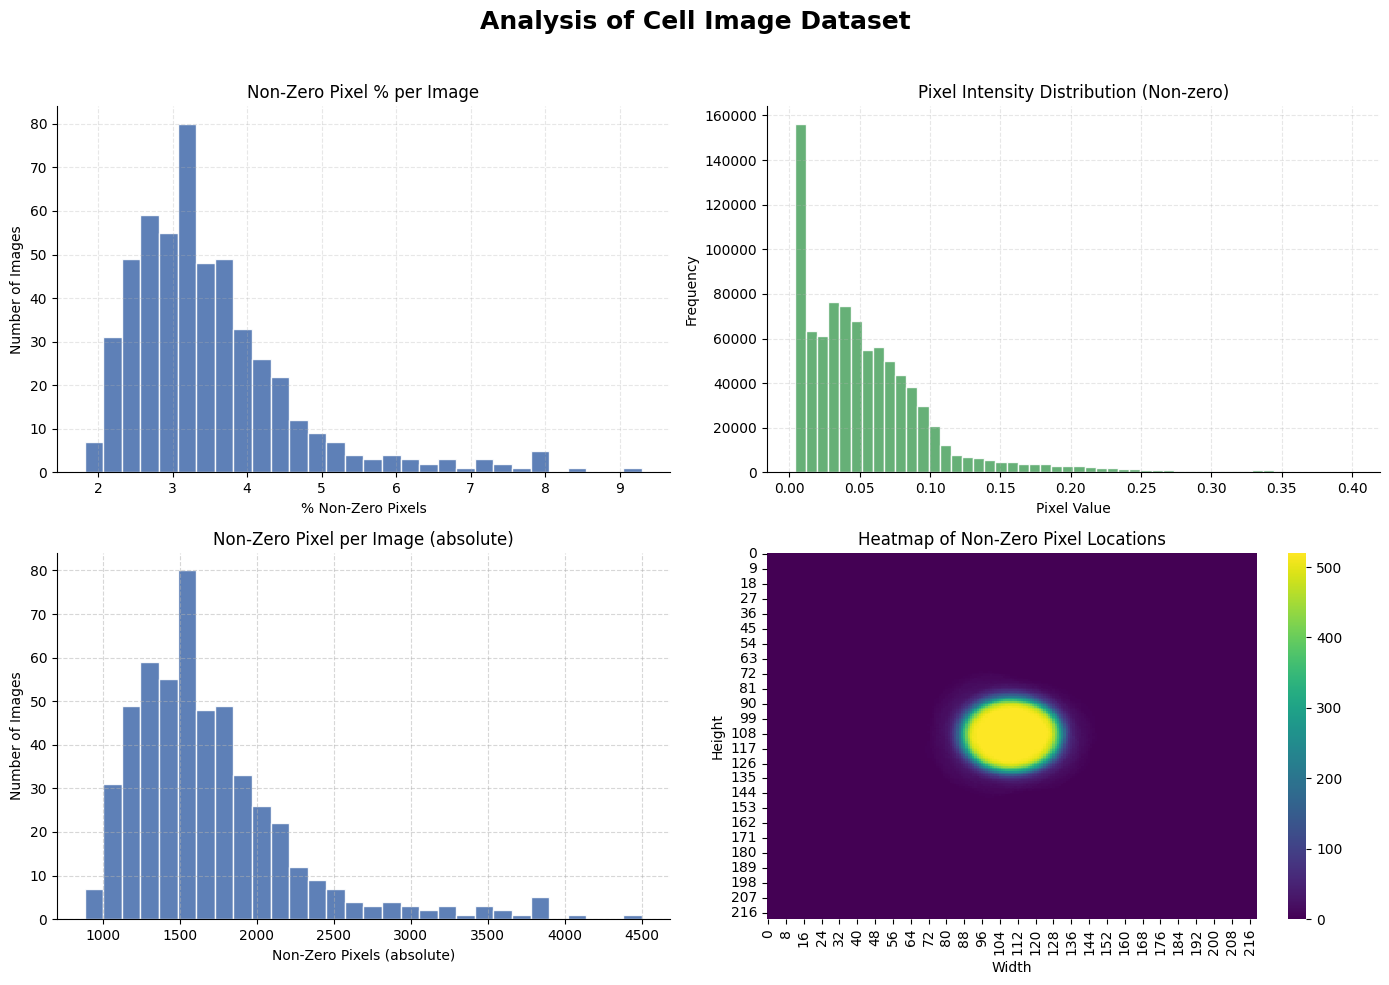

In [6]:
plot_pixel_stats(data)